# 🌊 Signal Processing Playground
Exploring waveform synthesis, FFTs, and spectrograms.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.style.use("dark_background")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 4)

print("✓ Ready")

✓ Ready


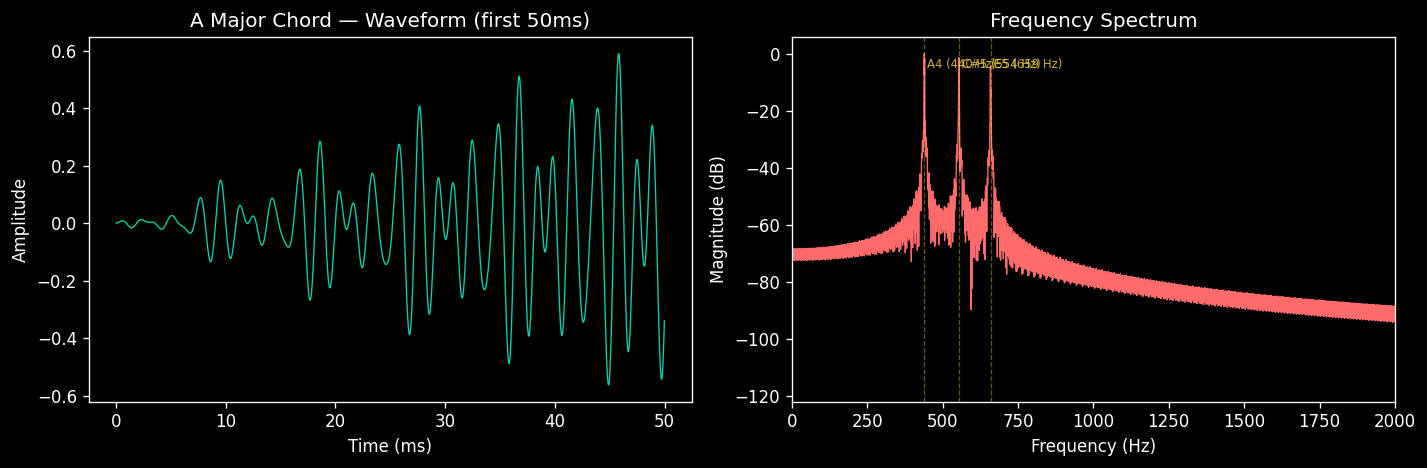

In [2]:
# Synthesize a chord: A major (A4 + C#5 + E5)
sr = 44100  # sample rate
duration = 2.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)

freqs = [440.0, 554.37, 659.25]  # A4, C#5, E5
labels = ["A4 (440 Hz)", "C#5 (554 Hz)", "E5 (659 Hz)"]

# Individual sine waves with slight detuning for warmth
signals = []
for i, f in enumerate(freqs):
    detune = np.sin(2 * np.pi * 0.5 * t) * 0.3  # subtle vibrato
    sig = np.sin(2 * np.pi * (f + detune) * t) * (0.8**i)
    signals.append(sig)

chord = sum(signals) / len(signals)

# Apply an ADSR envelope
attack, decay, sustain_level, release = 0.05, 0.1, 0.7, 0.3
envelope = np.ones_like(t)
a_samp = int(attack * sr)
d_samp = int(decay * sr)
r_samp = int(release * sr)
envelope[:a_samp] = np.linspace(0, 1, a_samp)
envelope[a_samp : a_samp + d_samp] = np.linspace(1, sustain_level, d_samp)
envelope[-r_samp:] = np.linspace(sustain_level, 0, r_samp)

chord *= envelope

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Waveform (first 50ms)
samples = int(0.05 * sr)
axes[0].plot(t[:samples] * 1000, chord[:samples], color="#00d4aa", linewidth=0.8)
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("A Major Chord — Waveform (first 50ms)")

# Spectrum
freqs_fft = np.fft.rfftfreq(len(chord), 1 / sr)
magnitude = np.abs(np.fft.rfft(chord))
magnitude_db = 20 * np.log10(magnitude / magnitude.max() + 1e-10)

axes[1].plot(freqs_fft, magnitude_db, color="#ff6b6b", linewidth=0.8)
axes[1].set_xlim(0, 2000)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude (dB)")
axes[1].set_title("Frequency Spectrum")
for f, label in zip([440.0, 554.37, 659.25], labels):
    axes[1].axvline(f, color="#ffd93d", alpha=0.4, linestyle="--", linewidth=0.8)
    axes[1].text(f + 10, -5, label, fontsize=7, color="#ffd93d", alpha=0.8)

plt.tight_layout()
plt.show()

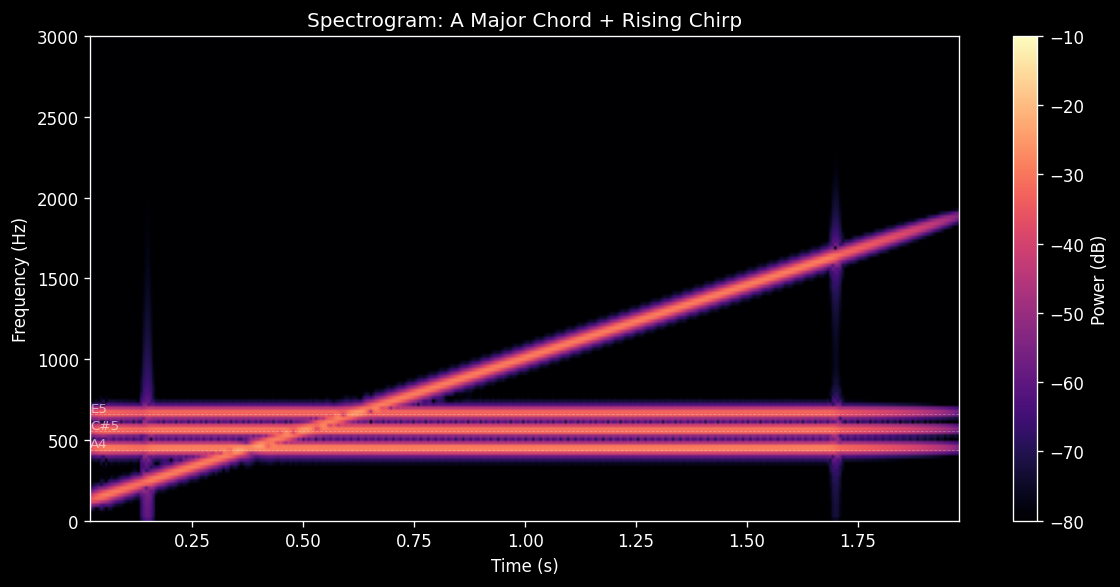

In [3]:
# Spectrogram — frequency sweep (chirp) mixed with the chord
chirp_freq = np.linspace(200, 2000, len(t))
chirp = 0.3 * np.sin(2 * np.pi * chirp_freq * t / 2) * envelope

mixed = chord + chirp

fig, ax = plt.subplots(figsize=(10, 5))
Pxx, freqs_spec, bins, im = ax.specgram(
    mixed, NFFT=2048, Fs=sr, noverlap=1800, cmap="magma", vmin=-80, vmax=-10
)
ax.set_ylim(0, 3000)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Spectrogram: A Major Chord + Rising Chirp")
plt.colorbar(im, ax=ax, label="Power (dB)")

# Annotate the chord fundamentals
for f, name in zip([440, 554, 659], ["A4", "C#5", "E5"]):
    ax.axhline(f, color="white", alpha=0.3, linewidth=0.5, linestyle="--")
    ax.text(0.02, f + 15, name, fontsize=8, color="white", alpha=0.6)

plt.tight_layout()
plt.show()